In [27]:
import os,sys
import json
import joblib
import numpy as np
import pandas as pd
import logging
import csv
from datetime import datetime
import tensorflow as tf
import time
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import shap

# 현재 노트북의 부모 폴더(human_A)를 경로에 추가
# /Users/jun/GitStudy/human_A/src가 위치한 곳을 찾기 위함입니다.
sys.path.append(os.path.join(os.path.abspath(os.path.join('..')),"src") )

# 우리가 만들어둔 '메인 셰프(파이프라인 매니저)' 모듈 불러오기
from feature_selection import run_feature_selection_experiment
from logger import get_logger, save_experiment_to_csv
from math_utils import calculate_sigma_thresholds
from model_builder import build_autoencoder
from utils import save_model_artifacts

/opt/homebrew/Caskroom/miniconda/base/envs/analyzer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
print(f"Python version: {sys.version}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
NumPy version:  2.2.6
Pandas version: 2.3.3


In [29]:
# 로거 생성
logger = get_logger("TRAIN")

In [30]:
import pltfont # mac 전용 한글 깨짐 라이브러리
pltfont.auto()

✅ 현재 폰트 적용됨: Arial Unicode MS


# 데이터 불러오기

In [31]:
df_raw =pd.read_csv("/Users/jun/GitStudy/human_A/data/generated_data_from_dabin_0420.csv")

# 데이터 상태 확인

In [32]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129600 entries, 0 to 129599
Data columns (total 47 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   timestamp                     129600 non-null  object 
 1   light_ppfd_umol_m2_s          129600 non-null  float64
 2   air_temp_c                    129600 non-null  float64
 3   relative_humidity_pct         129600 non-null  float64
 4   co2_ppm                       129600 non-null  float64
 5   raw_tank_level_pct            129600 non-null  float64
 6   raw_water_temp_c              129600 non-null  float64
 7   pump_rpm                      129600 non-null  float64
 8   flow_baseline_l_min           129600 non-null  float64
 9   flow_rate_l_min               129600 non-null  float64
 10  suction_pressure_kpa          129600 non-null  float64
 11  discharge_pressure_kpa        129600 non-null  float64
 12  motor_current_a               129600 non-nul

In [33]:
df_raw.describe()

,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_baseline_l_min,flow_rate_l_min,suction_pressure_kpa,...,zone2_pressure_kpa,zone2_substrate_moisture_pct,zone2_substrate_ec_ds_m,zone2_substrate_ph,zone3_flow_l_min,zone3_pressure_kpa,zone3_substrate_moisture_pct,zone3_substrate_ec_ds_m,zone3_substrate_ph,cleaning_event_flag
count,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,...,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000
mean,253.994713,23.242505,72.610537,735.008950,74.122271,19.742272,871.049631,77.994156,38.554317,-5.494169,...,87.934388,60.491267,2.138747,5.829989,12.658151,87.202578,61.024681,2.118217,5.819985,0.002778
std,259.364431,2.247647,7.960082,31.630375,0.137527,1.096417,871.201188,1.533842,38.587723,5.514674,...,2.759555,1.939508,0.071255,0.006026,12.666766,1.841782,1.372871,0.043664,0.006017,0.052632
min,0.000000,19.436000,55.295000,654.626000,73.626000,18.035000,0.000000,73.820000,0.000000,-12.824000,...,83.043000,56.224000,1.975000,5.804000,0.000000,82.567000,58.324000,1.986000,5.792000,0.000000
25%,39.766750,21.593000,64.598750,703.932750,74.028000,18.830000,0.000000,76.677000,0.000000,-10.693000,...,85.971000,59.846000,2.087000,5.826000,0.000000,85.908000,60.252000,2.085000,5.816000,0.000000
50%,90.636500,22.298000,76.882000,752.381500,74.125000,19.216000,846.013500,77.985000,33.930000,-4.992000,...,86.739000,60.841000,2.117000,5.830000,11.332000,86.589000,60.973000,2.113000,5.820000,0.000000
75%,512.331500,25.382000,79.411000,761.039000,74.219000,20.823000,1746.860000,79.320000,77.232000,0.000000,...,90.272000,61.444000,2.170000,5.834000,25.339000,88.539250,61.571000,2.151000,5.824000,0.000000
max,806.744000,28.235000,84.007000,783.025000,74.589000,22.159000,1816.966000,82.511000,82.106000,0.000000,...,98.086000,67.979000,2.324000,5.858000,27.211000,94.560000,67.792000,2.242000,5.849000,1.000000


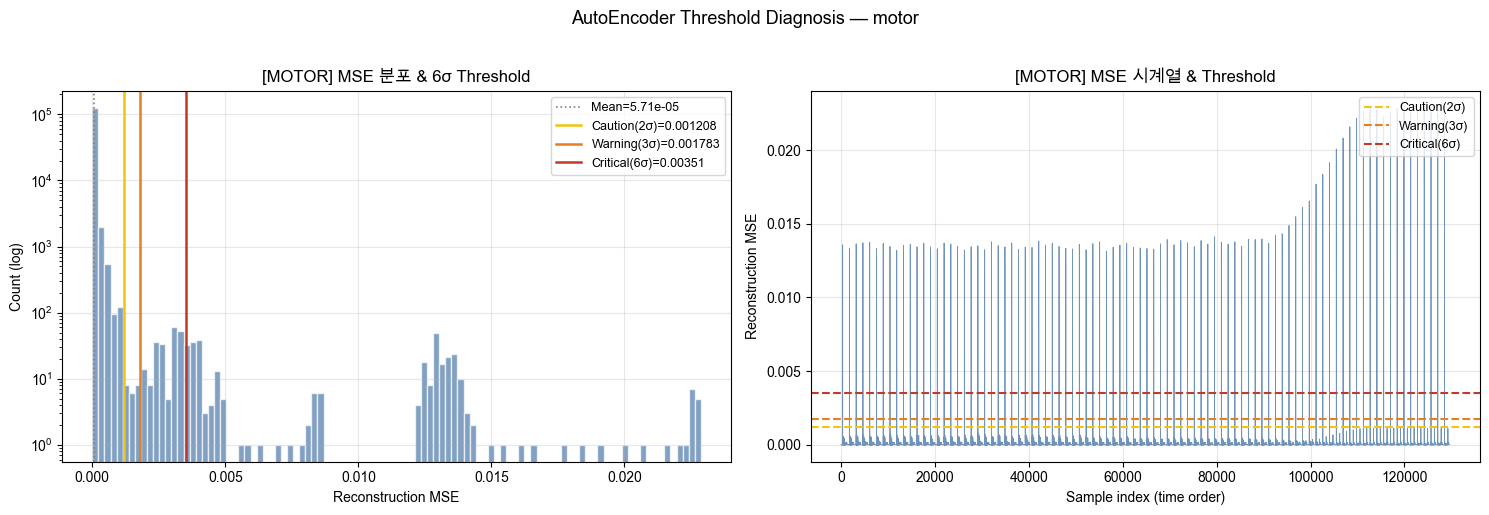

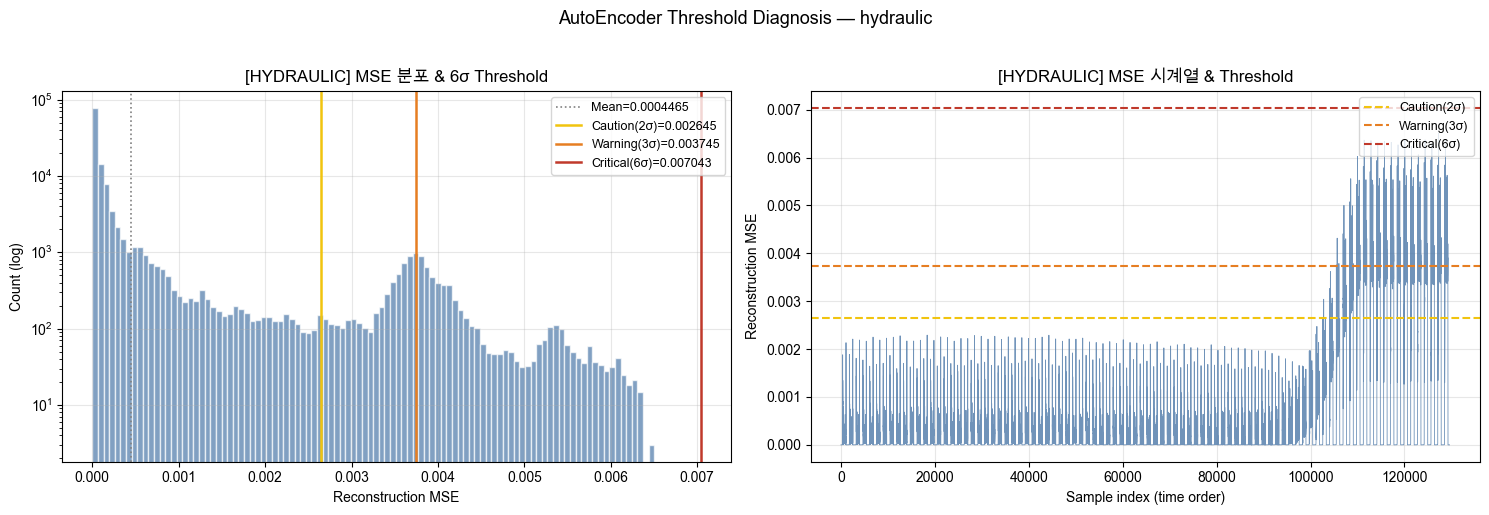

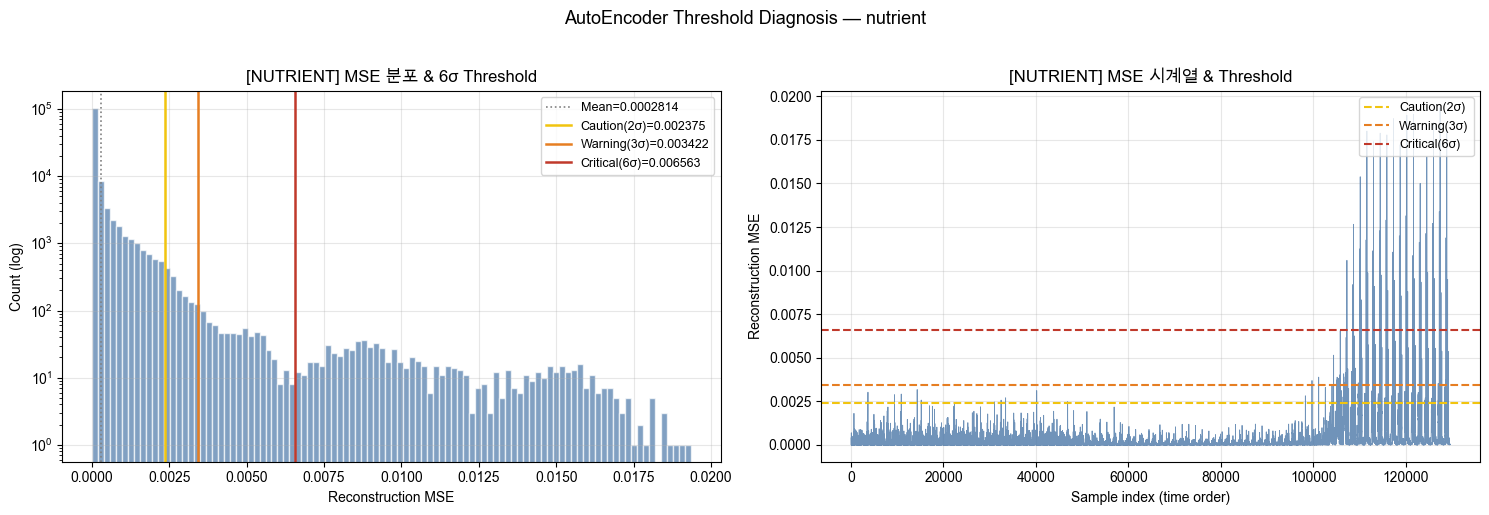

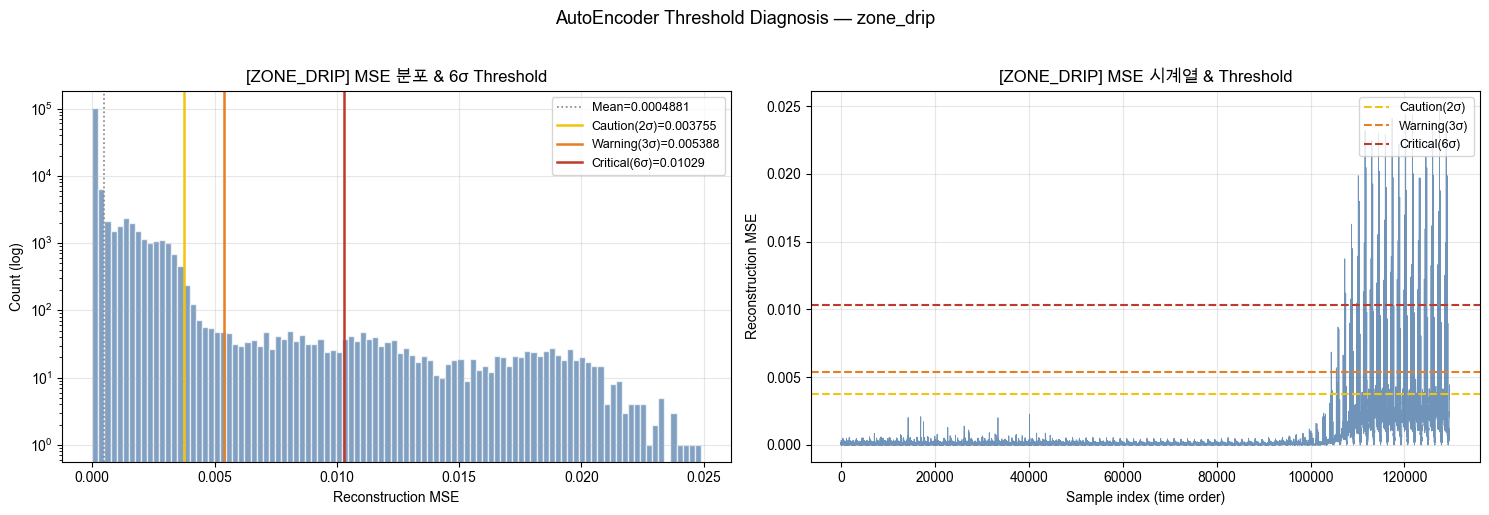

In [53]:
# ==============================================================================
# 📊 [Threshold 시각화] 도메인별 reconstruction error 분포 + 시계열 + 6σ 임계값
# ==============================================================================
import matplotlib.pyplot as plt

def plot_threshold(mse_scores, thresholds, model_name):
    """
    왼쪽: reconstruction error 히스토그램 (log y) + caution/warning/critical 수직선
    오른쪽: 시간순 reconstruction error 라인 + 동일한 threshold 가로선
    """
    t_caut = thresholds["caution"]
    t_warn = thresholds["warning"]
    t_crit = thresholds["critical"]
    t_mean = thresholds["mean"]

    fig, (ax_hist, ax_ts) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Left: histogram ---
    ax_hist.hist(mse_scores, bins=100, color="#4C78A8", alpha=0.7, edgecolor="white")
    ax_hist.set_yscale("log")
    ax_hist.axvline(t_mean, color="gray", linestyle=":", lw=1.2, label=f"Mean={t_mean:.4g}")
    ax_hist.axvline(t_caut, color="#F1C40F", lw=1.8, label=f"Caution(2σ)={t_caut:.4g}")
    ax_hist.axvline(t_warn, color="#E67E22", lw=1.8, label=f"Warning(3σ)={t_warn:.4g}")
    ax_hist.axvline(t_crit, color="#C0392B", lw=1.8, label=f"Critical(6σ)={t_crit:.4g}")
    ax_hist.set_xlabel("Reconstruction MSE")
    ax_hist.set_ylabel("Count (log)")
    ax_hist.set_title(f"[{model_name.upper()}] MSE 분포 & 6σ Threshold")
    ax_hist.legend(loc="upper right", fontsize=9)
    ax_hist.grid(True, alpha=0.3)

    # --- Right: time series ---
    ax_ts.plot(mse_scores, color="#4C78A8", lw=0.6, alpha=0.8)
    ax_ts.axhline(t_caut, color="#F1C40F", lw=1.5, linestyle="--", label="Caution(2σ)")
    ax_ts.axhline(t_warn, color="#E67E22", lw=1.5, linestyle="--", label="Warning(3σ)")
    ax_ts.axhline(t_crit, color="#C0392B", lw=1.5, linestyle="--", label="Critical(6σ)")
    ax_ts.set_xlabel("Sample index (time order)")
    ax_ts.set_ylabel("Reconstruction MSE")
    ax_ts.set_title(f"[{model_name.upper()}] MSE 시계열 & Threshold")
    ax_ts.legend(loc="upper right", fontsize=9)
    ax_ts.grid(True, alpha=0.3)

    fig.suptitle(f"AutoEncoder Threshold Diagnosis — {model_name}", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


for name, result in all_results.items():
    if result is None:
        continue
    mse_scores, thresholds = result
    plot_threshold(mse_scores, thresholds, name)


In [ ]:
# ==============================================================================
# 💡 [저장 모델 로드 → 평가 → 시각화]  입력: 모델 경로 + 데이터 CSV
#   - 학습 셀 필요 없음. {domain}_model.keras / _scaler.pkl / _config.json 만 있으면
#     MSE · threshold 를 현재 데이터 분포 기준으로 다시 계산하고 plot_threshold 로 시각화.
# ==============================================================================
from preprocessing import step1_prepare_window_data
from inference_core import actionable_feature_mask

# 👉 여기만 경로 바꿔가며 실험
model_path = "/Users/jun/GitStudy/human_A/models"
data_path  = "/Users/jun/GitStudy/human_A/data/generated_data_from_dabin_0420.csv"

subsystem_targets = {
    "motor": {
        "motor_current_a": [
            "motor_power_kw", "motor_temperature_c",
            "wire_to_water_efficiency", "bearing_vibration_rms_mm_s",
        ],
        "rpm_stability_index": ["pump_rpm"],
    },
    "hydraulic": {
        "zone1_resistance": ["zone1_pressure_kpa", "zone1_flow_l_min"],
        "differential_pressure_kpa": ["discharge_pressure_kpa", "suction_pressure_kpa"],
    },
    "nutrient": {
        "pid_error_ec": ["mix_ec_ds_m", "mix_target_ec_ds_m"],
        "salt_accumulation_delta": ["drain_ec_ds_m", "mix_ec_ds_m"],
    },
    "zone_drip": {
        "zone1_moisture_response_pct": ["zone1_substrate_moisture_pct"],
        "zone1_ec_accumulation": ["zone1_substrate_ec_ds_m", "mix_ec_ds_m"],
    },
}


def load_saved_artifacts(model_dir, model_name):
    cfg_path    = os.path.join(model_dir, f"{model_name}_config.json")
    scaler_path = os.path.join(model_dir, f"{model_name}_scaler.pkl")
    keras_path  = os.path.join(model_dir, f"{model_name}_model.keras")
    with open(cfg_path, "r", encoding="utf-8") as f:
        config = json.load(f)
    return {
        "config": config,
        "scaler": joblib.load(scaler_path),
        "model":  tf.keras.models.load_model(keras_path, compile=False),
    }


def evaluate_saved_model(df_raw, model_dir, model_name, target_dict):
    artifacts = load_saved_artifacts(model_dir, model_name)
    config, scaler, model = artifacts["config"], artifacts["scaler"], artifacts["model"]

    target_cols = list(set(target_dict.keys()) | set(config["features"]))
    df_agg, df_interpret = step1_prepare_window_data(
        df_raw, window_method="sliding", target_cols=target_cols
    )

    df_eval = df_agg.copy()
    for col in config["features"]:
        if col not in df_eval.columns and col in df_interpret.columns:
            df_eval[col] = df_interpret[col]

    missing = [c for c in config["features"] if c not in df_eval.columns]
    if missing:
        raise KeyError(f"[{model_name}] 필요한 피처가 없습니다: {missing}")

    X_scaled = scaler.transform(df_eval[config["features"]].copy())
    recon = model.predict(X_scaled, verbose=0)
    sq_err = np.power(X_scaled - recon, 2)

    scoring_features = config.get("scoring_features")
    if scoring_features:
        scoring_mask = np.array([c in scoring_features for c in config["features"]])
    else:
        scoring_mask = actionable_feature_mask(config["features"])
    if scoring_mask.sum() == 0:
        scoring_mask = np.ones(len(config["features"]), dtype=bool)

    mse_scores = np.mean(sq_err[:, scoring_mask], axis=1)

    # 현재 데이터 분포 기준 threshold 재계산 (저장된 값은 saved_* 로 함께 보관)
    thresholds = calculate_sigma_thresholds(mse_scores, sigma_levels=(2, 3, 6))
    thresholds["saved_caution"]  = float(config["threshold_caution"])
    thresholds["saved_warning"]  = float(config["threshold_warning"])
    thresholds["saved_critical"] = float(config["threshold_critical"])
    thresholds["saved_mean"] = float(
        config.get("metrics", {}).get("final_mse_mean", np.mean(mse_scores))
    )
    print(
        f"[{model_name}] current mean={thresholds['mean']:.6f}, "
        f"current critical={thresholds['critical']:.6f} | "
        f"saved critical={thresholds['saved_critical']:.6f}"
    )
    return mse_scores, thresholds


# ── 실행 ──────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(data_path)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])
df_raw = df_raw.set_index("timestamp")

all_results = {}
for system_name, target_dict in subsystem_targets.items():
    cfg_file = os.path.join(model_path, f"{system_name}_config.json")
    if not os.path.exists(cfg_file):
        print(f"[SKIP] {system_name}: config 파일이 없습니다.")
        continue
    print(f"[LOAD] {system_name} 모델 평가 중...")
    all_results[system_name] = evaluate_saved_model(
        df_raw=df_raw, model_dir=model_path,
        model_name=system_name, target_dict=target_dict,
    )

print(f"\n✅ 저장된 모델 로드 및 reconstruction error 계산 완료 ({len(all_results)} 도메인)")

# ── 도메인별 threshold 시각화 ─────────────────────────────────────────────
for system_name, (mse_scores, thresholds) in all_results.items():
    plot_threshold(mse_scores, thresholds, system_name)


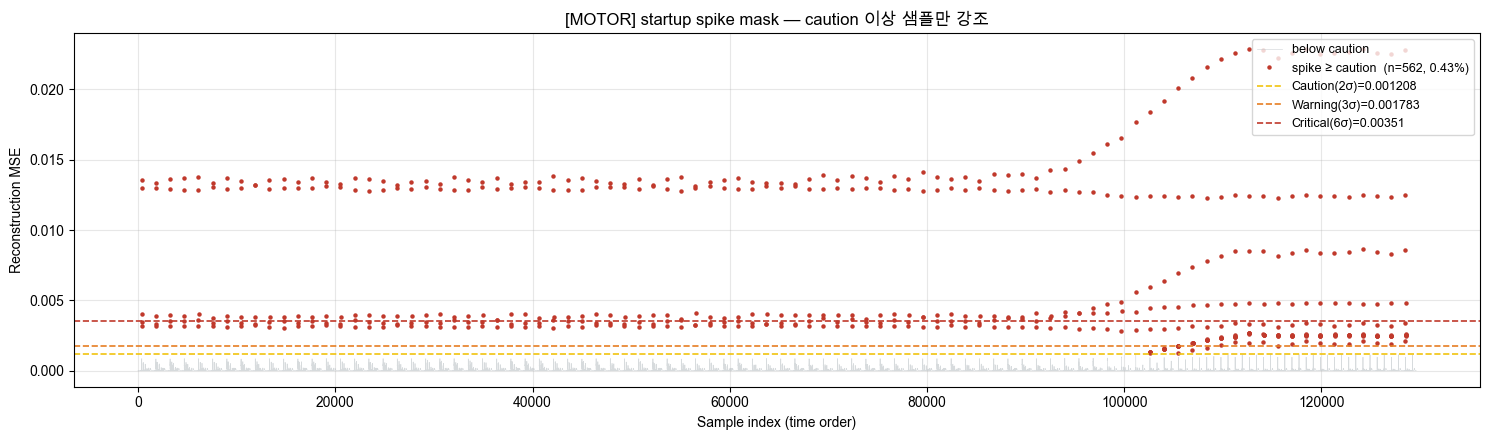

In [54]:
# ==============================================================================
# 📍 [Motor Spike Mask] startup spike 위주만 골라 보여주는 단일 플롯
#  - caution(2σ) 이상 샘플만 빨간 점으로 표시
#  - 나머지는 옅은 회색 배경으로 깔아서 컨텍스트만 유지
# ==============================================================================
motor_result = all_results.get("motor")
if motor_result is None:
    print("[motor] all_results에 결과 없음 — 메인 셀 먼저 실행하세요.")
else:
    mse_scores, thresholds = motor_result
    n = len(mse_scores)

    spike_mask = mse_scores > thresholds["caution"]
    spike_vals = np.where(spike_mask, mse_scores, np.nan)
    bg_vals    = np.where(~spike_mask, mse_scores, np.nan)

    n_spike = int(spike_mask.sum())
    pct = n_spike / n * 100

    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.plot(bg_vals,    color="#BDC3C7", lw=0.5, alpha=0.6, label="below caution")
    ax.plot(spike_vals, color="#C0392B", lw=0.0, marker="o", markersize=2.2,
            label=f"spike ≥ caution  (n={n_spike:,}, {pct:.2f}%)")
    ax.axhline(thresholds["caution"],  color="#F1C40F", lw=1.2, linestyle="--",
               label=f"Caution(2σ)={thresholds['caution']:.4g}")
    ax.axhline(thresholds["warning"],  color="#E67E22", lw=1.2, linestyle="--",
               label=f"Warning(3σ)={thresholds['warning']:.4g}")
    ax.axhline(thresholds["critical"], color="#C0392B", lw=1.2, linestyle="--",
               label=f"Critical(6σ)={thresholds['critical']:.4g}")
    ax.set_title("[MOTOR] startup spike mask — caution 이상 샘플만 강조")
    ax.set_xlabel("Sample index (time order)")
    ax.set_ylabel("Reconstruction MSE")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
